In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN

from sklearn.metrics import silhouette_score
from datasist.structdata import detect_outliers
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Wholesale_customers_data.csv')

In [3]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [4]:
df.shape

(440, 8)

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


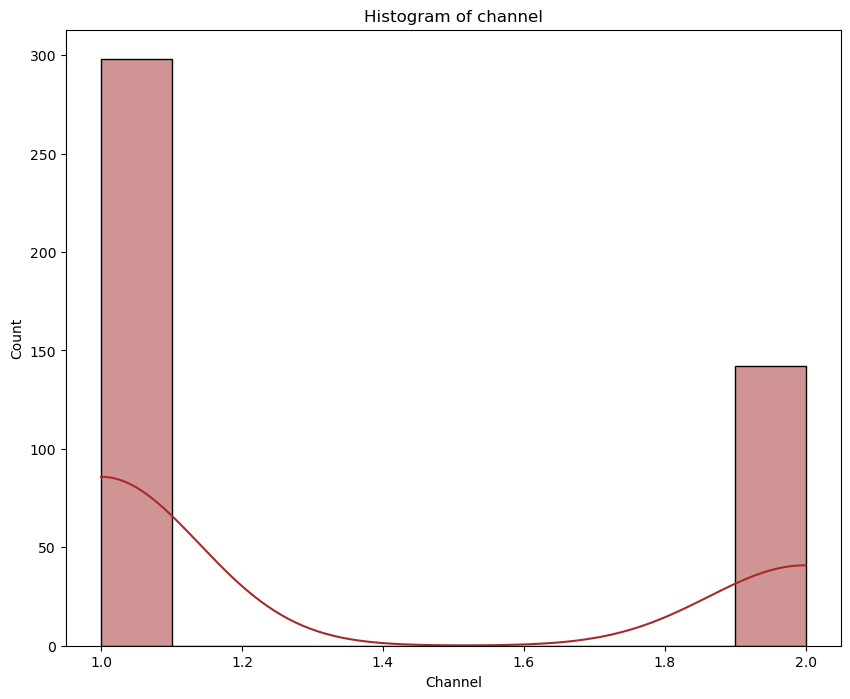

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Channel',color='brown',kde=True,ax=ax)
plt.title('Histogram of channel')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.show()

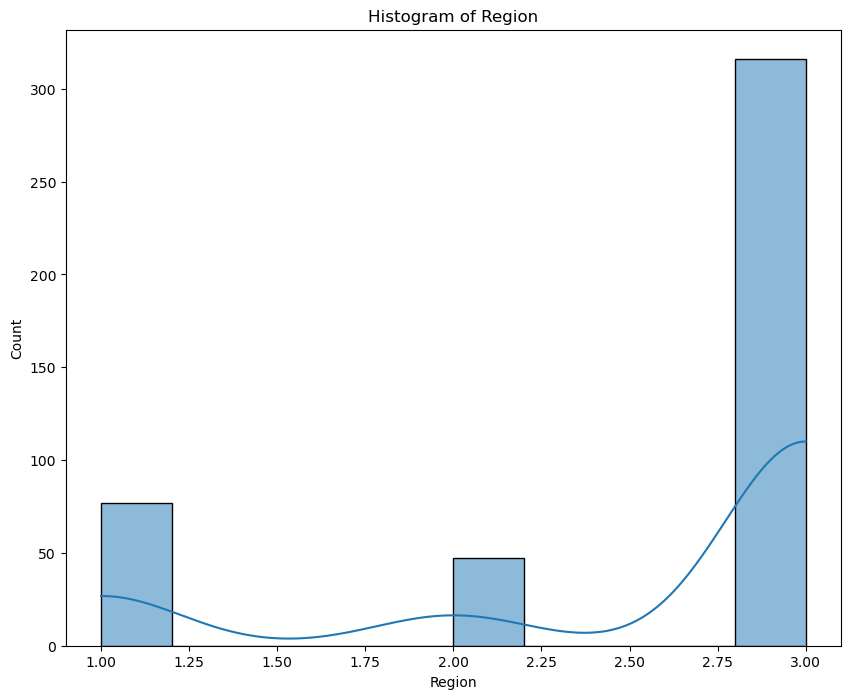

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Region',kde=True,ax=ax)
plt.title('Histogram of Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

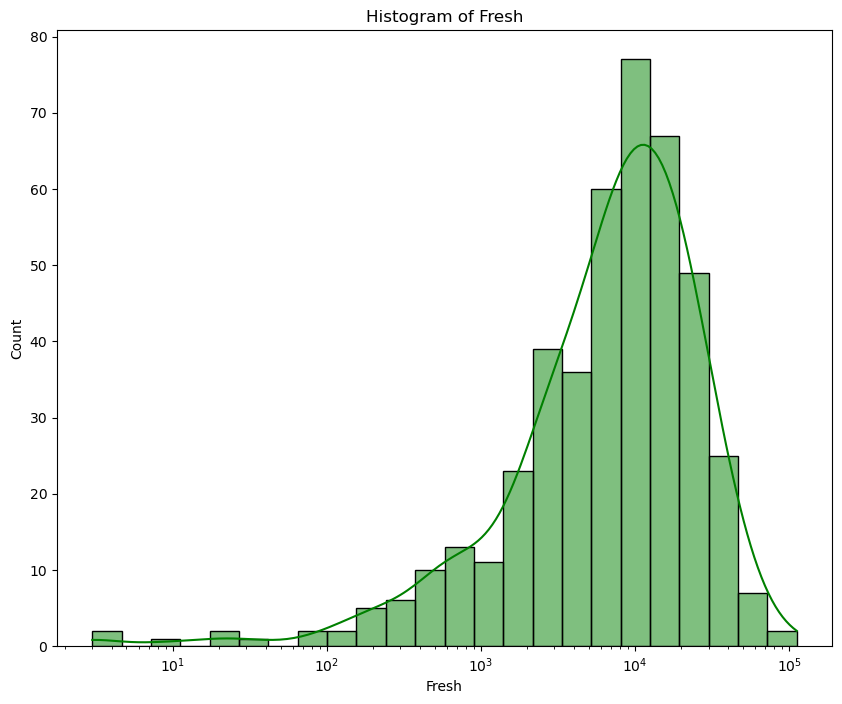

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Fresh',kde=True,color='green',log_scale=True,ax=ax)
plt.title('Histogram of Fresh')
plt.xlabel('Fresh')
plt.ylabel('Count')
plt.show()

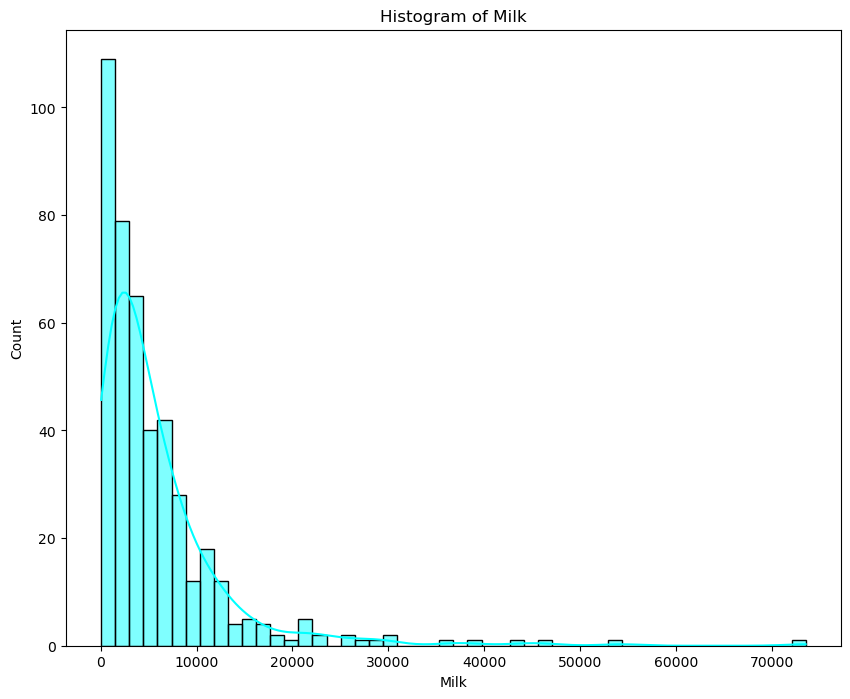

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Milk',kde=True,color='cyan',ax=ax)
plt.title('Histogram of Milk')
plt.xlabel('Milk')
plt.ylabel('Count')
plt.show()

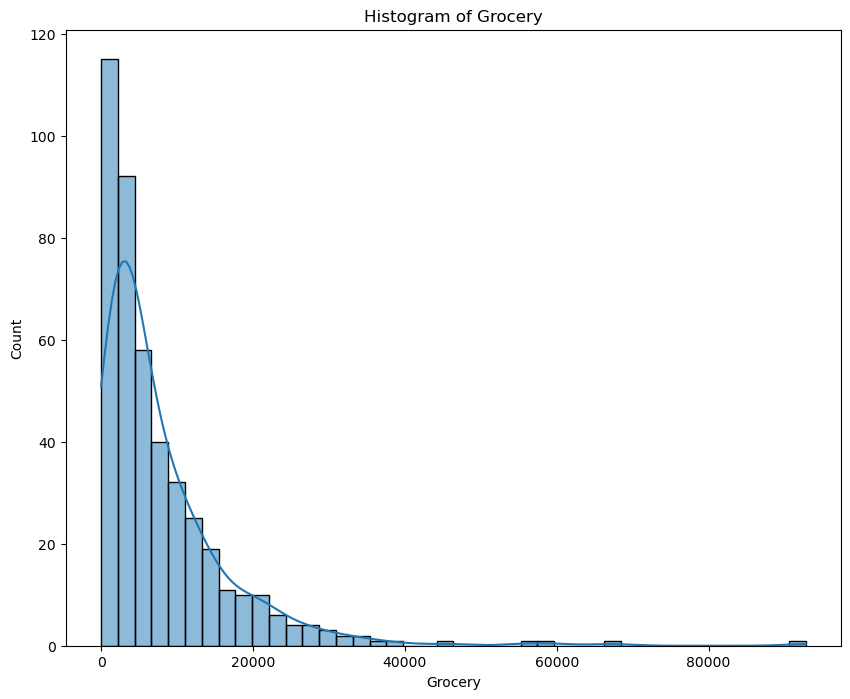

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Grocery',kde=True,ax=ax)
plt.title('Histogram of Grocery')
plt.xlabel('Grocery')
plt.ylabel('Count')
plt.show()

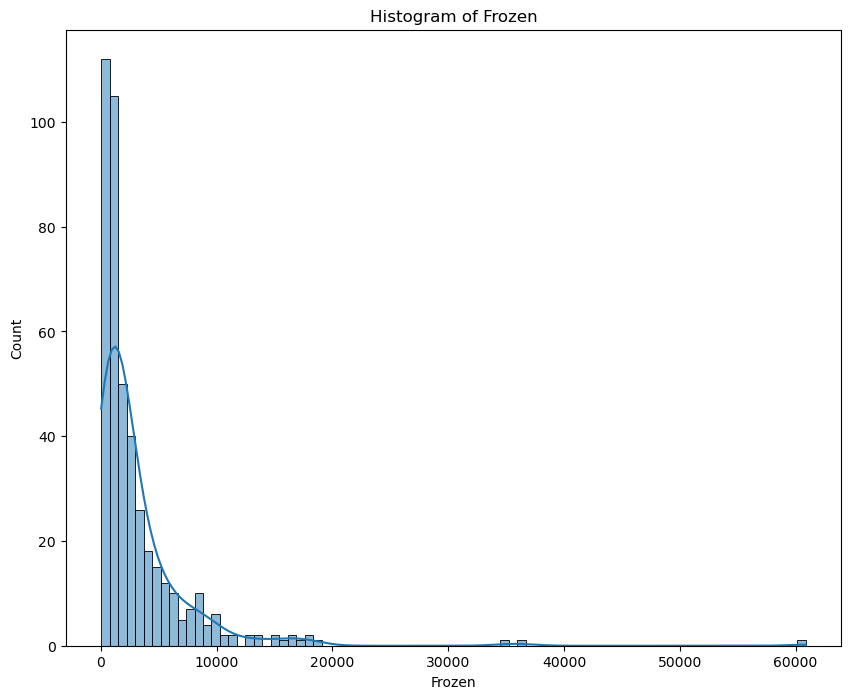

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Frozen',kde=True,ax=ax)
plt.title('Histogram of Frozen')
plt.xlabel('Frozen')
plt.ylabel('Count')
plt.show()

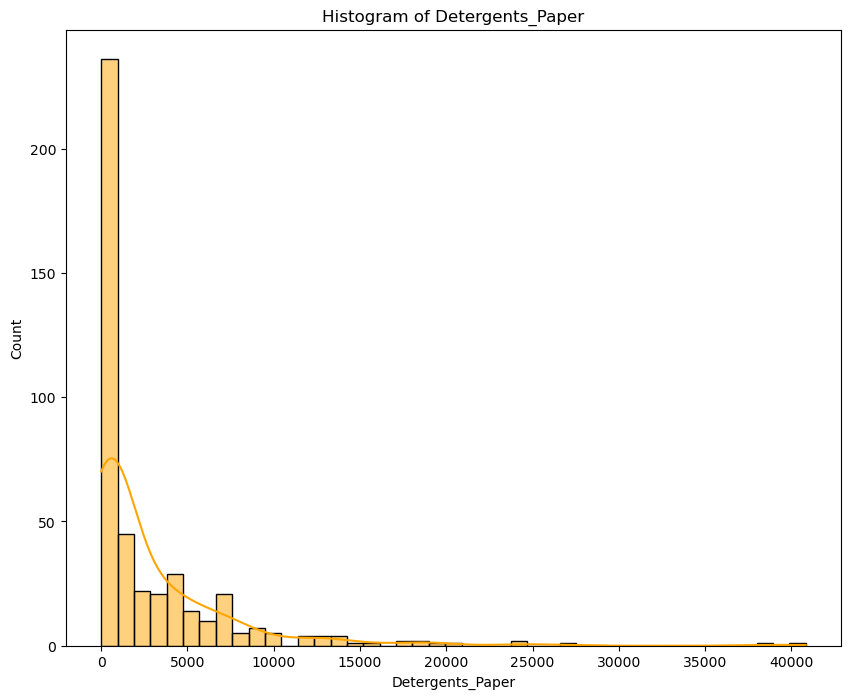

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Detergents_Paper',color='orange',kde=True,ax=ax)
plt.title('Histogram of Detergents_Paper')
plt.xlabel('Detergents_Paper')
plt.ylabel('Count')
plt.show()

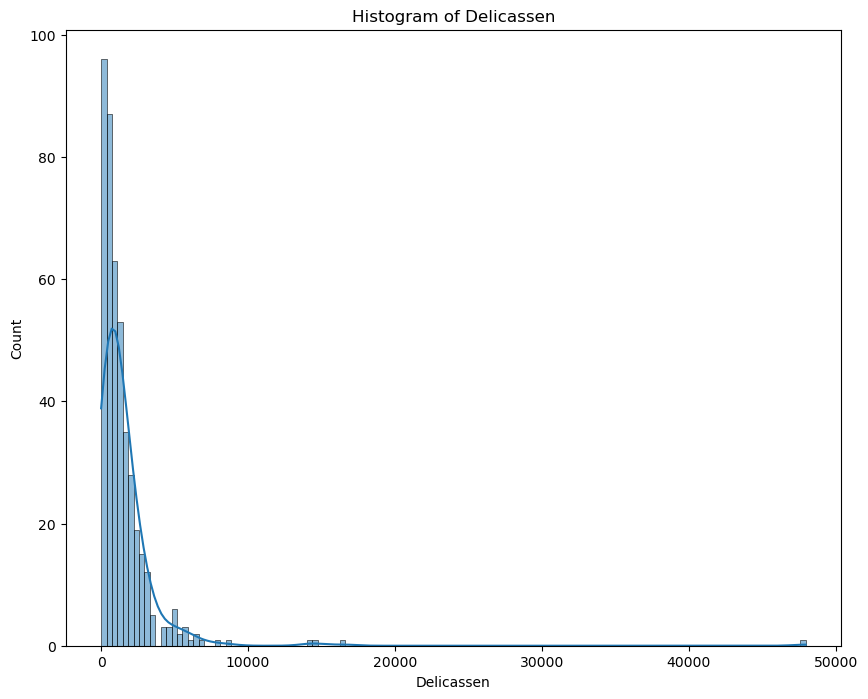

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(df,x='Delicassen',kde=True,ax=ax)
plt.title('Histogram of Delicassen')
plt.xlabel('Delicassen')
plt.ylabel('Count')
plt.show()

In [15]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Text(0.5, 1.0, 'Correlation between dataset')

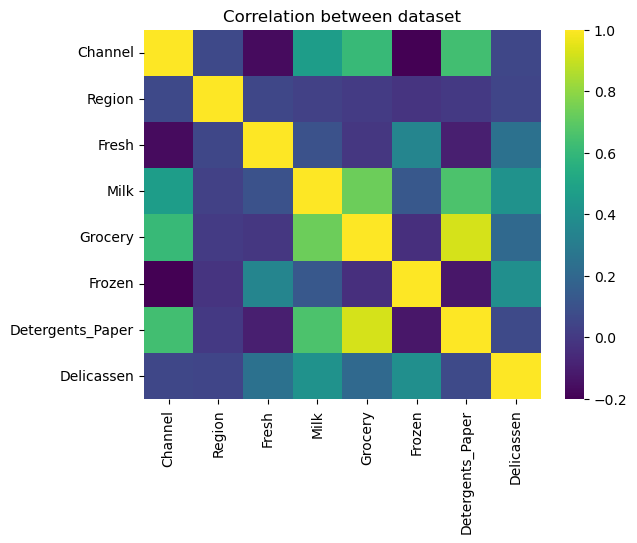

In [16]:
corr=df.corr()
sns.heatmap(corr,cmap='viridis')
plt.title('Correlation between dataset')

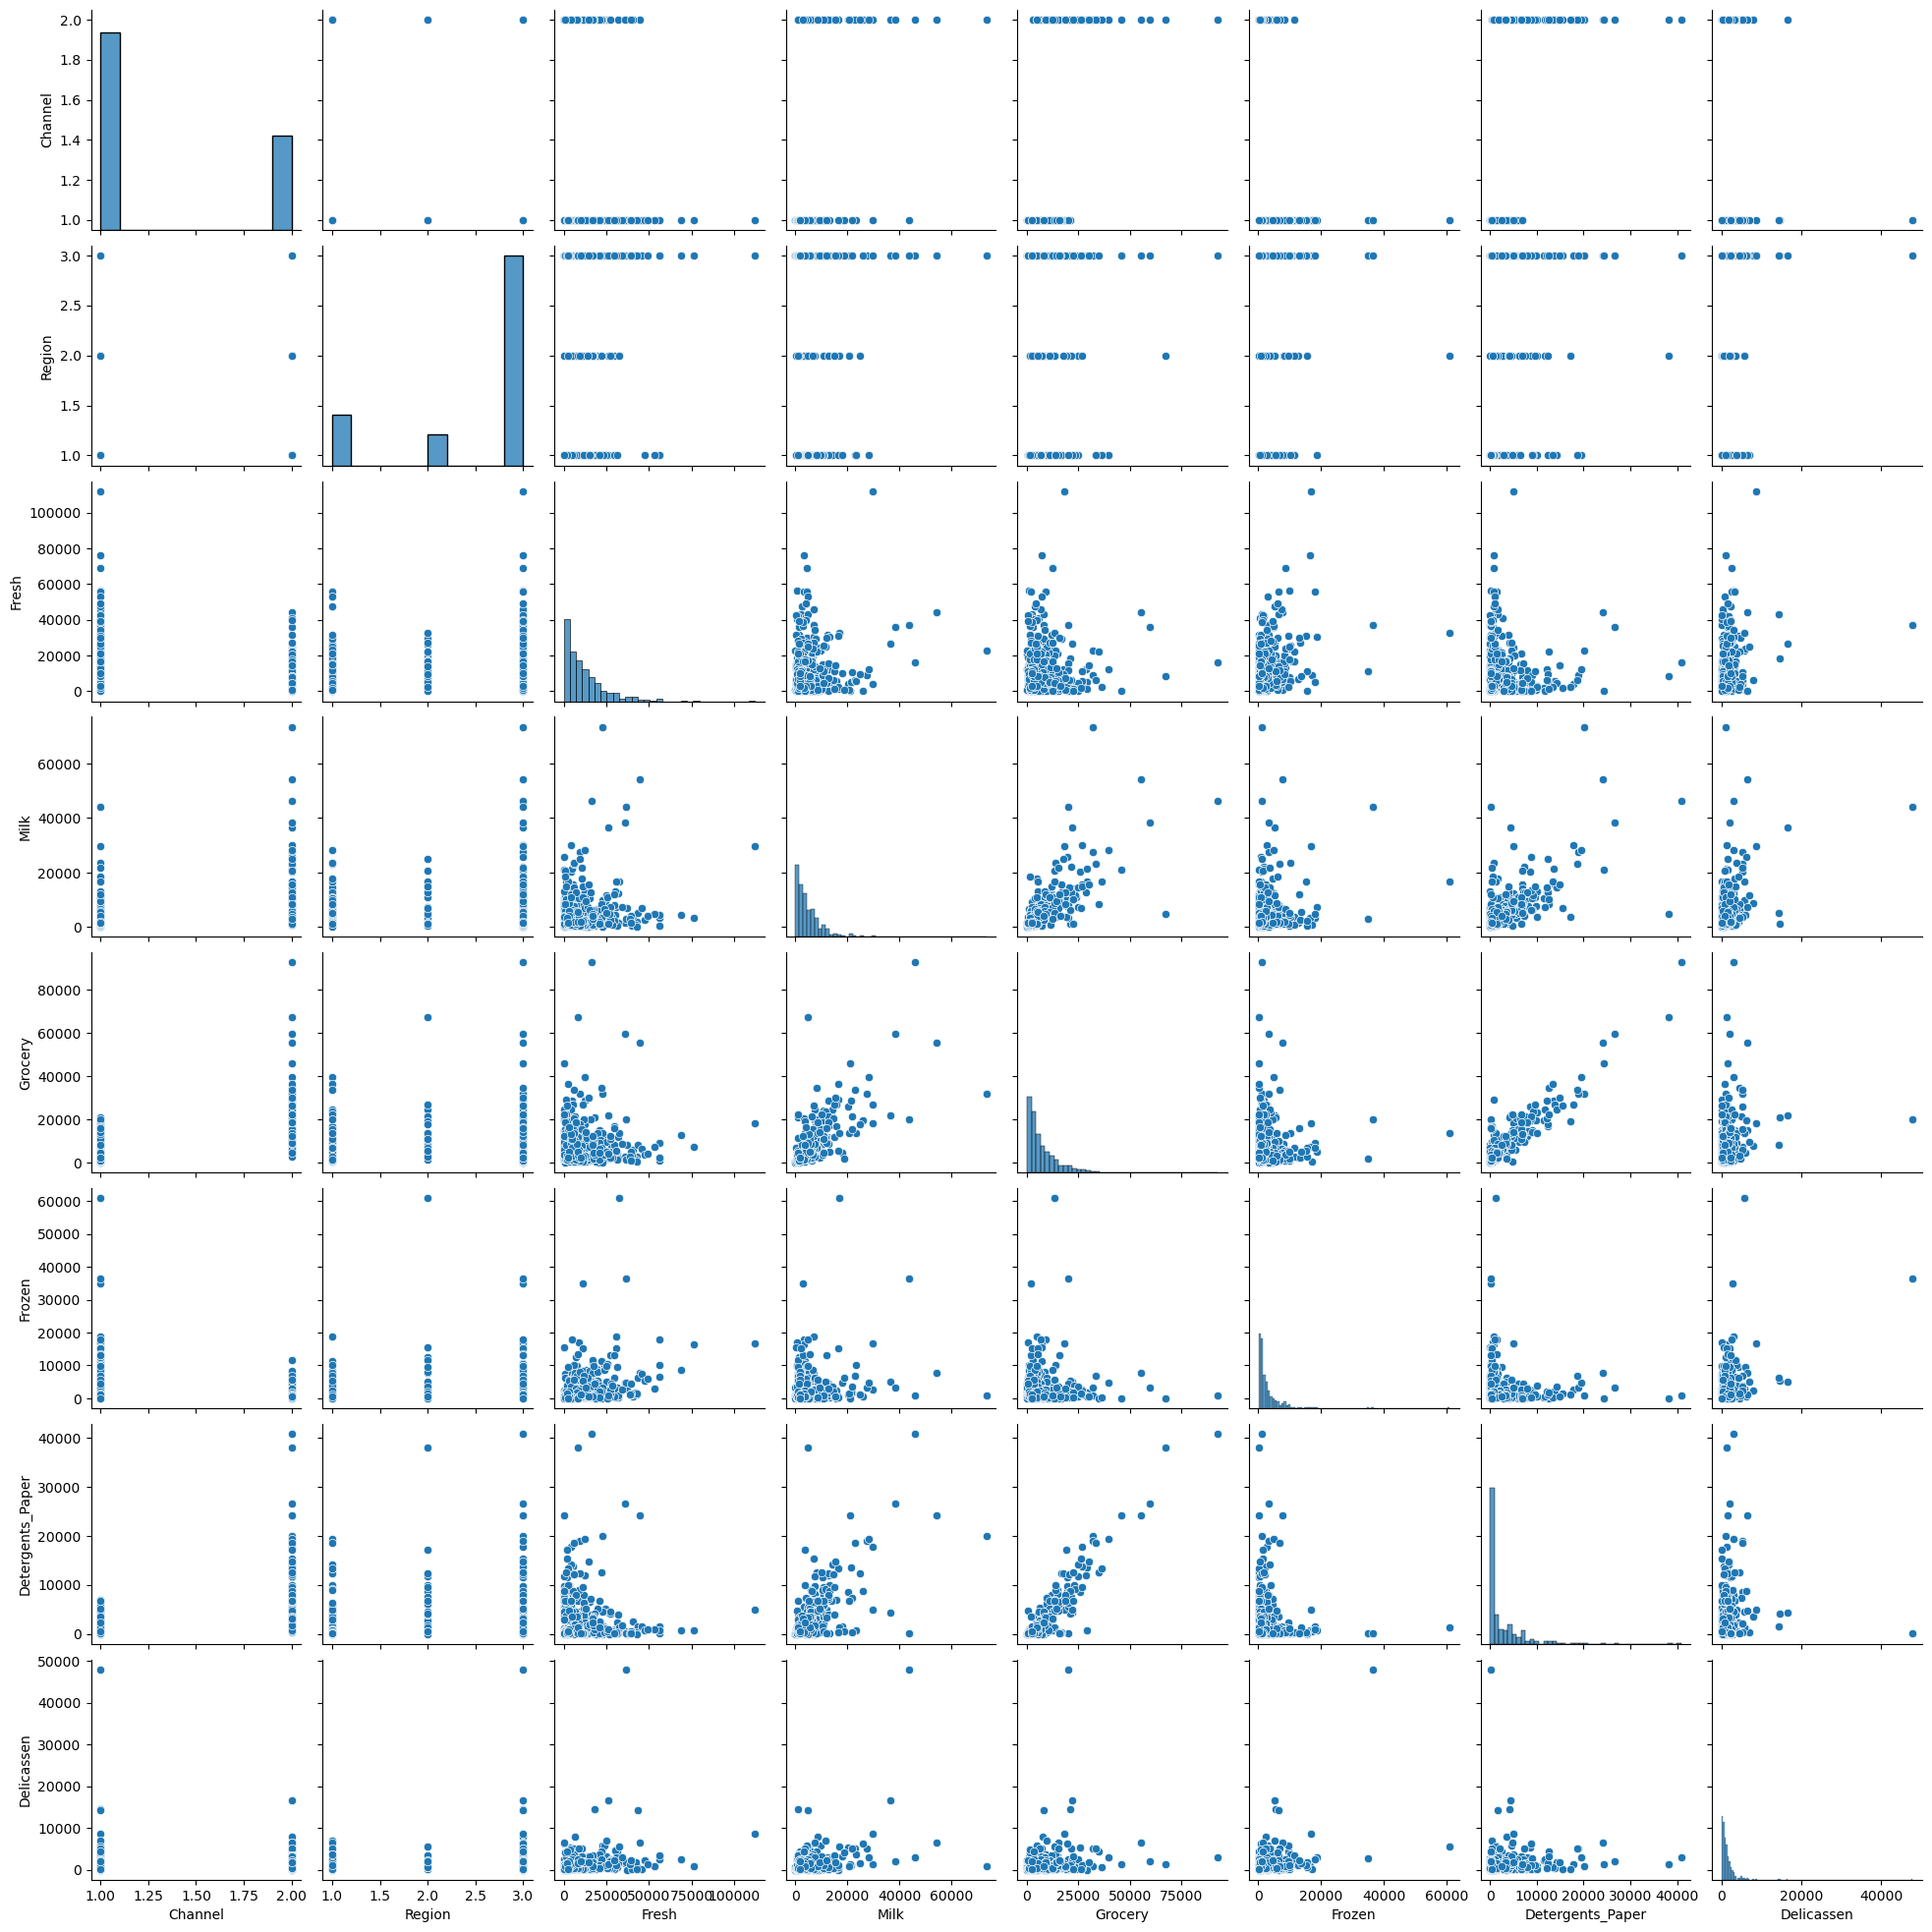

In [17]:
sns.pairplot(df)

In [18]:
len(detect_outliers(df,0,df.columns))

108

In [19]:
df.drop(detect_outliers(df , 0 , df.columns) , axis = 0 , inplace = True)

In [20]:
df.reset_index(inplace = True , drop = True )

#### Modeling with Kmeans

In [21]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [28]:
Numercal_data=df.columns[2:].tolist()

In [29]:
Numercal_data

['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

##### Solve Skewness Problem

In [30]:
Target=np.log(df[Numercal_data])

###### Scaling

In [31]:
Scaler=StandardScaler()

In [32]:
scaled_data=Scaler.fit_transform(Target)

#### Define k

In [37]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

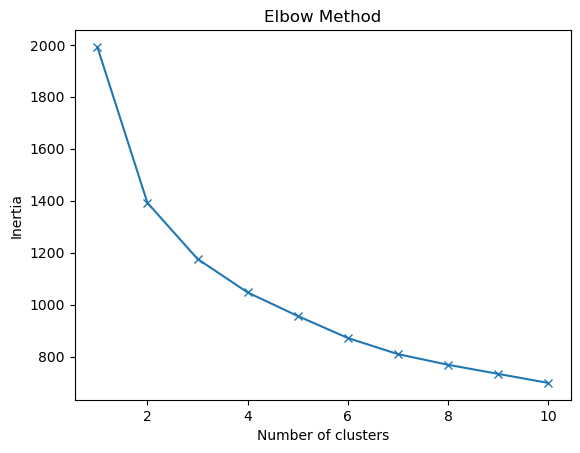

In [38]:
plt.plot(range(1, 11), inertia, marker='x')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [54]:
k=2

In [55]:
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)


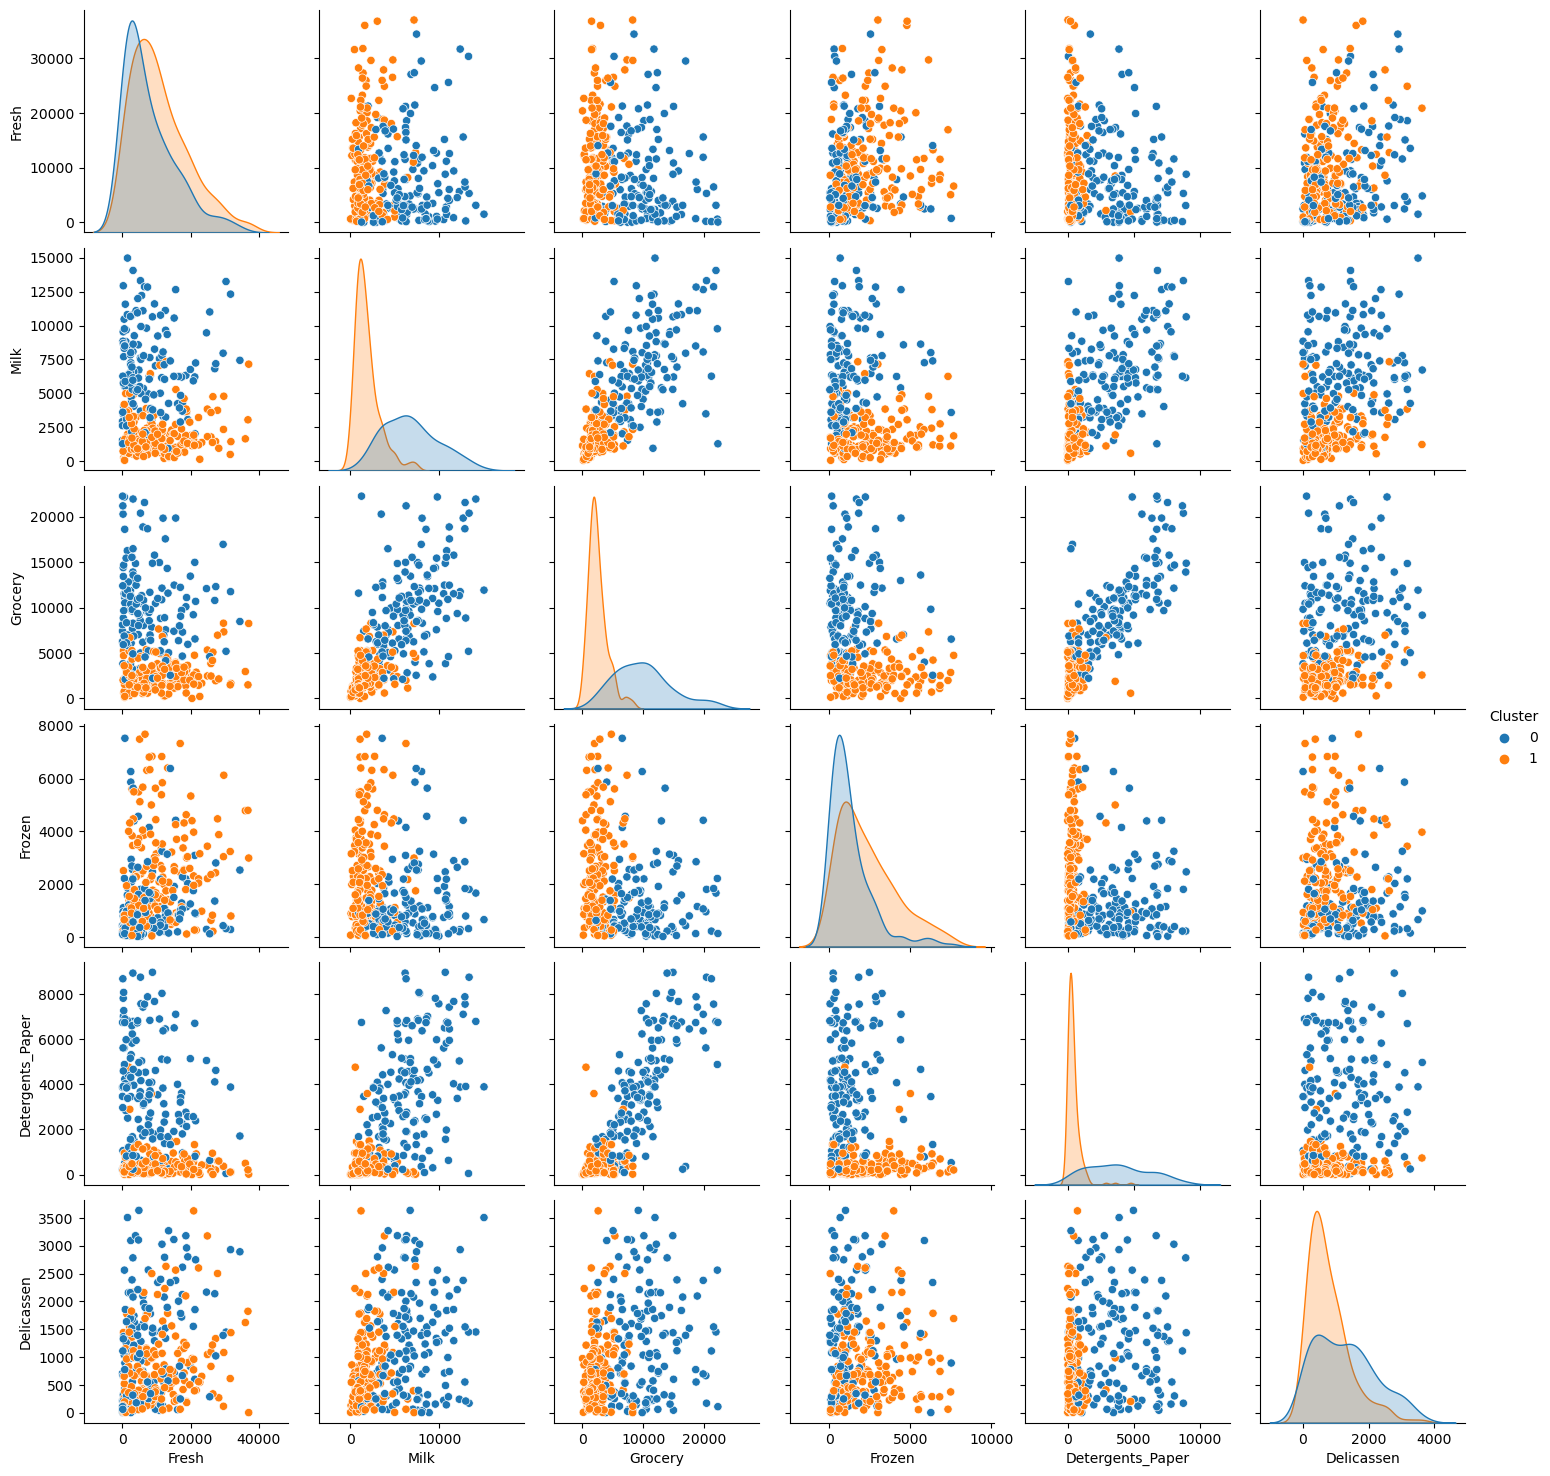

In [56]:
sns.pairplot(data=df, hue='Cluster',vars=Numercal_data )
plt.show()

## Modeling with Dbscan

In [115]:
Model = DBSCAN(eps=1 , min_samples=7) 

In [116]:
df['cluster_Dxb']=Model.fit_predict(scaled_data)

In [117]:
Model.labels_

array([-1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,
        0,  0, -1,  0,  0,  0, -1,  0, -1, -1, -1,  0,  0, -1, -1,  0,  0,
       -1, -1, -1,  0,  0, -1,  0, -1, -1,  0,  0,  0, -1,  0, -1, -1,  0,
       -1, -1,  0, -1,  0, -1,  0,  0, -1,  0,  0, -1, -1, -1, -1, -1,  0,
        0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1, -1,  0,  0, -1, -1, -1,  0,  0,  0,  0,  0, -1, -1,  0,
        0, -1, -1, -1,  0,  0, -1,  0,  0, -1,  0, -1, -1,  0,  0,  0, -1,
        0, -1,  0, -1,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1,  0,
       -1, -1, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  0,  0,  0, -1, -1,
        0, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0,  0,
        0, -1,  0, -1,  0, -1,  0, -1,  0, -1,  0,  0,  0,  0,  0, -1,  0,
       -1,  0, -1,  0,  0, -1, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0,  0,
       -1, -1,  0, -1,  0, -1, -1,  0,  0,  0,  0,  0, -1,  0, -1,  0, -1,
        0, -1,  0,  0,  0

In [118]:
unique_labels=np.unique(Model.labels_)
for label in unique_labels:
    if label != -1:
        num_points_in_cluster= np.sum(Model.labels_ == label)
        print(f'Cluster {label}: {num_points_in_cluster} data points')

Cluster 0: 202 data points


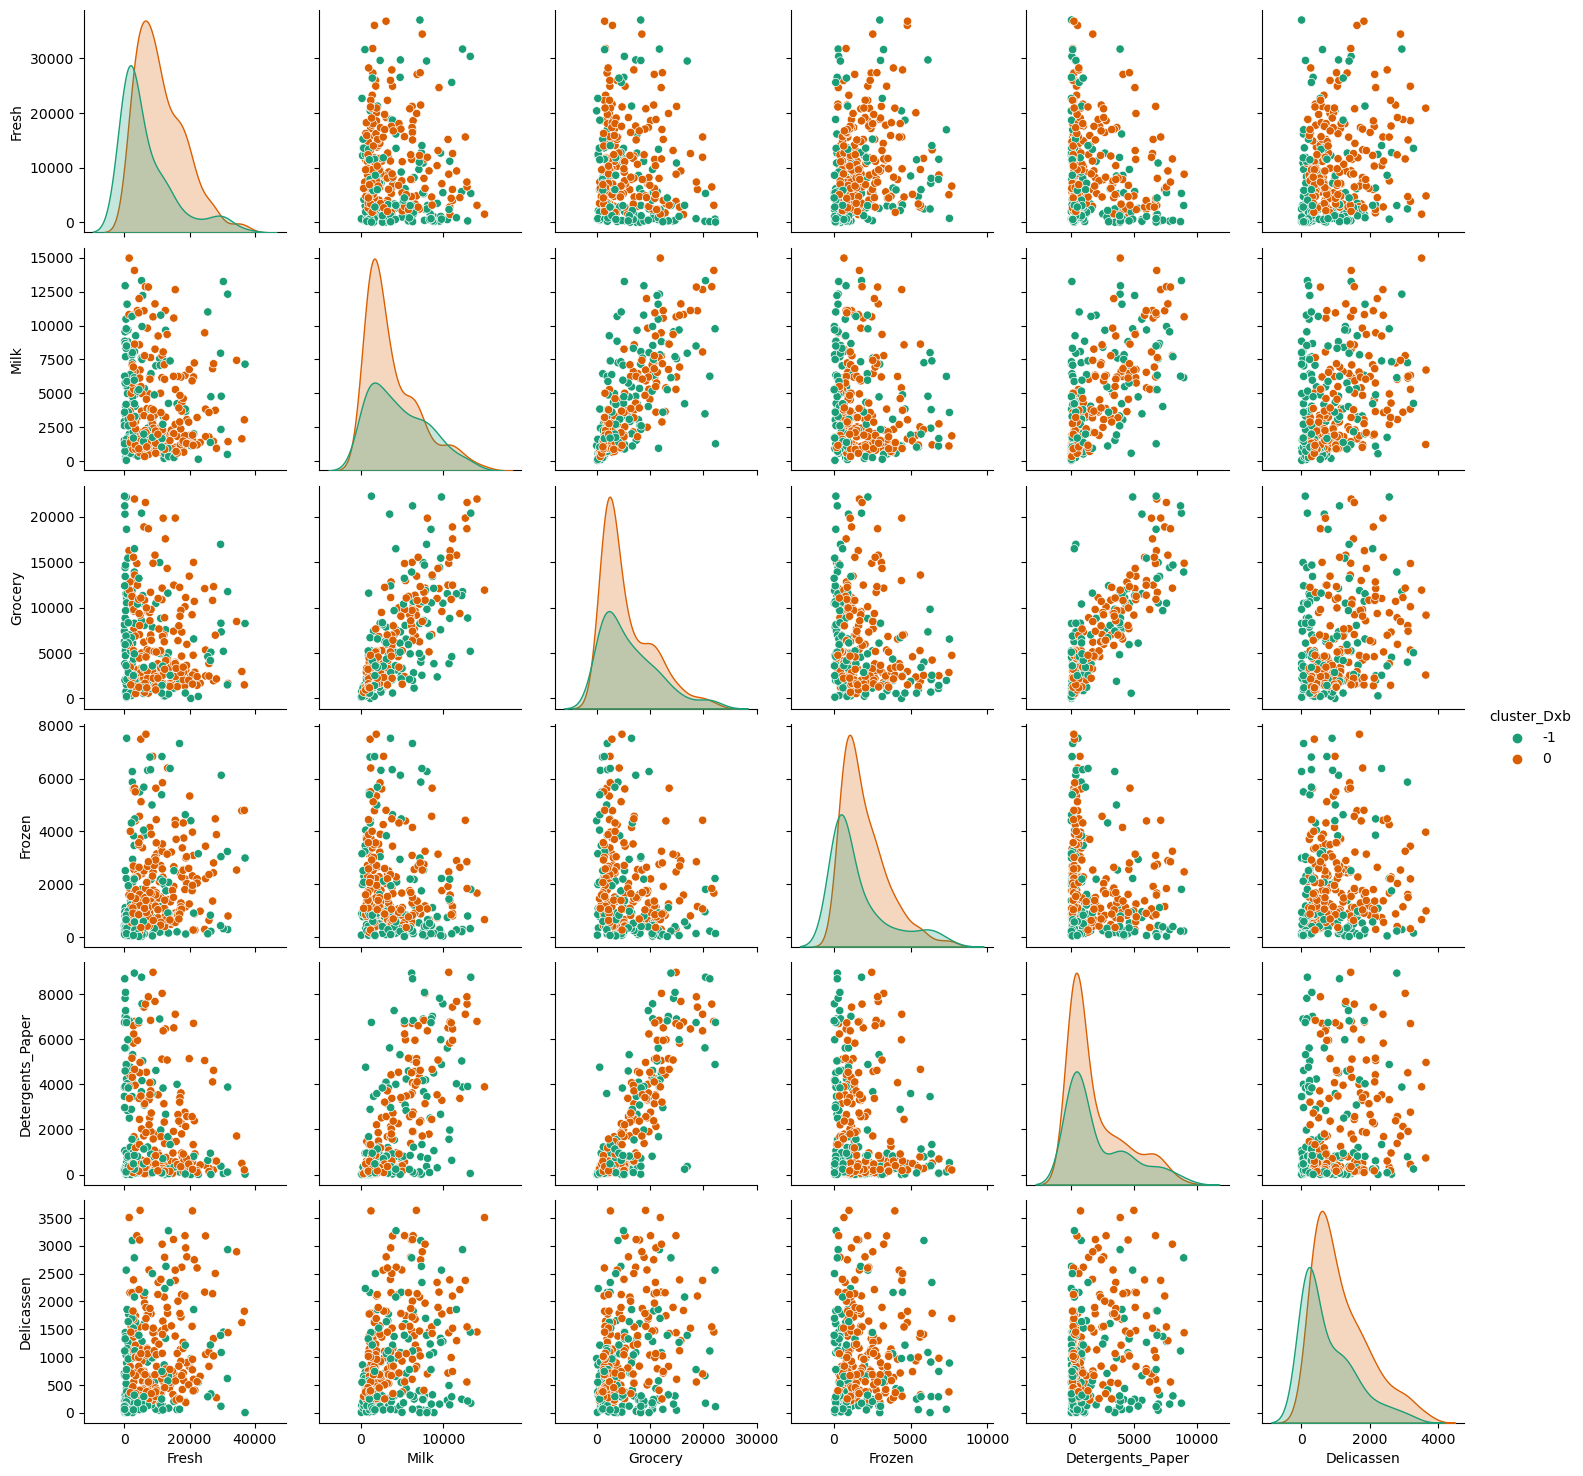

In [119]:
sns.pairplot(data=df, hue='cluster_Dxb',vars=Numercal_data,palette='Dark2' )
plt.show()